Here we fill the null values by random values using refrence from other datas from the column.

we can't do thisi in sklearn instrad we do this in pandas.

Also we should use this if we are using linear based algorithm not tree based algorithm.


In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [3]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [4]:
df.isnull().mean() * 100

,0
Survived,0.00000
Age,19.86532
Fare,0.00000


In [5]:

X = df.drop(columns=['Survived'])
y = df['Survived']

In [6]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [7]:

X_train

,Age,Fare
30,40.0,27.7208
10,4.0,16.7000
873,47.0,9.0000
182,9.0,31.3875
876,20.0,9.8458
...,...,...
534,30.0,8.6625
584,NaN,8.7125
493,71.0,49.5042
527,NaN,221.7792


In [8]:

X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [9]:

X_test.tail()

,Age,Fare,Age_imputed
89,24.0,8.0500,24.0
80,22.0,9.0000,22.0
846,NaN,69.5500,NaN
870,26.0,7.8958,26.0
251,29.0,10.4625,29.0


In [10]:
X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
X_test['Age_imputed'][X_test['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_test['Age'].isnull().sum()).values

/tmp/ipython-input-10-3090101260.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
/tmp/ipython-input-10-3090101

In [11]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

array([23.  , 35.  , 52.  , 11.  , 22.  , 33.  , 18.  , 16.  ,  5.  ,
       20.  ,  0.75,  4.  , 38.  ,  3.  , 21.  , 32.  , 33.  , 24.  ,
       34.  , 30.  , 51.  , 34.5 , 14.  , 23.  , 63.  ,  1.  , 21.  ,
       29.  , 19.  , 39.  , 27.  , 32.  , 13.  , 36.  , 43.  , 23.  ,
       29.  , 27.  ,  4.  , 18.  , 25.  , 33.  , 23.  ,  2.  , 20.  ,
       47.  , 22.  , 25.  , 31.  , 43.  , 40.  , 35.  , 70.  , 33.  ,
       21.  , 16.  , 25.  , 31.  , 28.  , 26.  , 65.  , 34.  , 36.  ,
       48.  , 28.  , 61.  , 14.  , 29.  , 22.  , 48.  ,  9.  ,  2.  ,
       18.  , 48.  , 24.  , 33.  , 35.  , 51.  , 60.  ,  9.  , 20.  ,
       54.  , 59.  , 25.  , 45.  , 33.  ,  4.  , 29.  , 30.  , 24.  ,
       26.  , 27.  , 51.  , 16.  , 45.  , 27.  ,  3.  , 40.  , 16.  ,
       25.  , 30.  , 32.  , 42.  , 53.  ,  1.  , 61.  , 29.  ,  2.  ,
       35.  ,  7.  ,  8.  , 52.  , 34.  , 40.  , 14.  , 21.  , 50.  ,
       25.  , 27.  , 50.  ,  0.83, 23.  , 30.  , 31.  , 30.  , 50.  ,
       25.  , 24.  ,

In [12]:

X_train['Age'].isnull().sum()

np.int64(148)

In [13]:

X_train

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,35.0
493,71.0,49.5042,71.0
527,NaN,221.7792,34.0


/tmp/ipython-input-14-2642582470.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'],label='Original',hist=False)


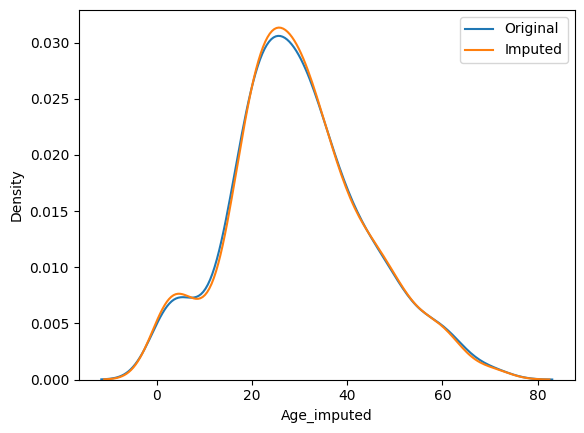

In [14]:
sns.distplot(X_train['Age'],label='Original',hist=False)
sns.distplot(X_train['Age_imputed'],label = 'Imputed',hist=False)

plt.legend()
plt.show()

In [15]:
print('Original variable variance: ', X_train['Age'].var())
print('Variance after random imputation: ', X_train['Age_imputed'].var())

Original variable variance:  204.3495133904614
Variance after random imputation:  202.68852401191526


In [16]:

X_train[['Fare', 'Age', 'Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,53.246691
Age,71.512440,204.349513,204.349513
Age_imputed,53.246691,204.349513,202.688524


<Axes: >

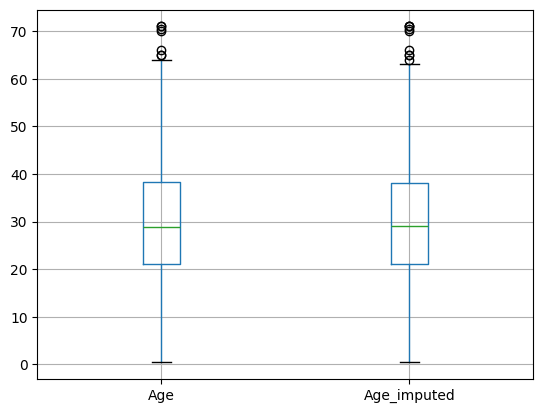

In [17]:

X_train[['Age', 'Age_imputed']].boxplot()

In [19]:
def impute_age(observation):
    return X_train['Age'].dropna().sample(1, random_state=int(observation['Fare'])).values[0]

X_train['Age'] = X_train.apply(lambda row: impute_age(row) if pd.isnull(row['Age']) else row['Age'], axis=1)


# Next Dataset

In [20]:
data = pd.read_csv('house-train.csv',usecols=['GarageQual','FireplaceQu', 'SalePrice'])

In [21]:

data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [22]:

data.isnull().mean() * 100

,0
FireplaceQu,47.260274
GarageQual,5.547945
SalePrice,0.000000


In [23]:
X = data
y = data['SalePrice']

In [24]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [25]:
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [26]:
X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
601,Gd,TA,141000,TA,Gd
999,NaN,TA,206000,TA,NaN
1129,NaN,TA,140000,TA,NaN
167,Gd,TA,325624,TA,Gd
284,NaN,TA,179200,TA,NaN


In [27]:

temp = pd.concat(
        [
            X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
            X_train['GarageQual_imputed'].value_counts() / len(X_train)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

In [28]:

temp

,original,imputed
TA,0.951043,0.898116
Fa,0.037171,0.035103
Gd,0.009973,0.009418
Po,0.000907,0.000856
Ex,0.000907,0.000856


In [29]:

temp = pd.concat(
        [
            X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()),
            X_train['FireplaceQu_imputed'].value_counts() / len(df)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

temp

,original,imputed
Gd,0.494272,0.338945
TA,0.412439,0.282828
Fa,0.040917,0.028058
Po,0.027823,0.019080
Ex,0.024550,0.016835


/tmp/ipython-input-30-2695486330.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'],hist=False,label=category)
/tmp/ipython-input-30-2695486330.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['Firepla

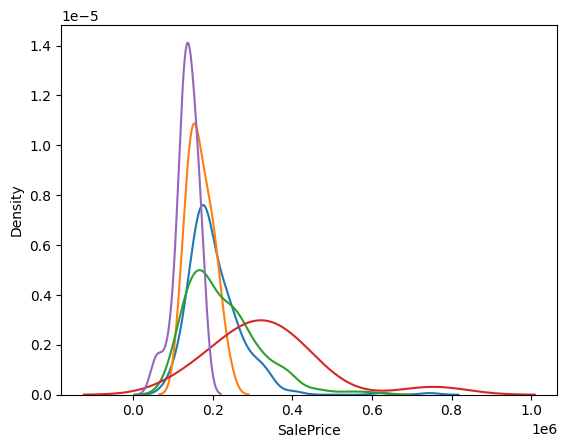

In [30]:

for category in X_train['FireplaceQu'].dropna().unique():
    sns.distplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'],hist=False,label=category)
plt.show()

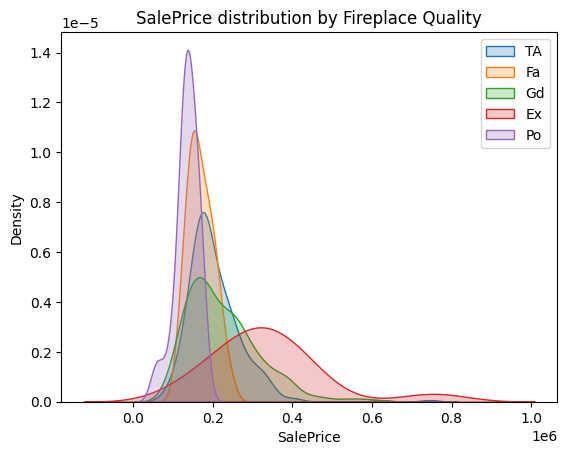

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

# Loop over each category in the 'FireplaceQu_imputed' column
for category in X_train['FireplaceQu_imputed'].dropna().unique():
    # Plot the distribution of 'SalePrice' for each category
    sns.kdeplot(
        data=X_train[X_train['FireplaceQu_imputed'] == category],
        x='SalePrice',
        label=category,
        fill=True  # Optional: fills the area under the curve
    )

# Show the legend and plot
plt.legend()
plt.title('SalePrice distribution by Fireplace Quality')
plt.show()
